In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# Load data
df = pd.read_csv('full_image_data_feb_25.csv', low_memory=False)

In [3]:
target_cks = [
    'CK_Great and Small Circles Definition'
]

# Drop na
df_clean = df.dropna(subset=['year', 'place', 'custom_identifier']).copy()

# Convert custom_identifier
try:
    df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(float).astype(int).astype(str)
except Exception as e:
    df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(str)

filtered = df_clean[df_clean['cks'].isin(target_cks)]

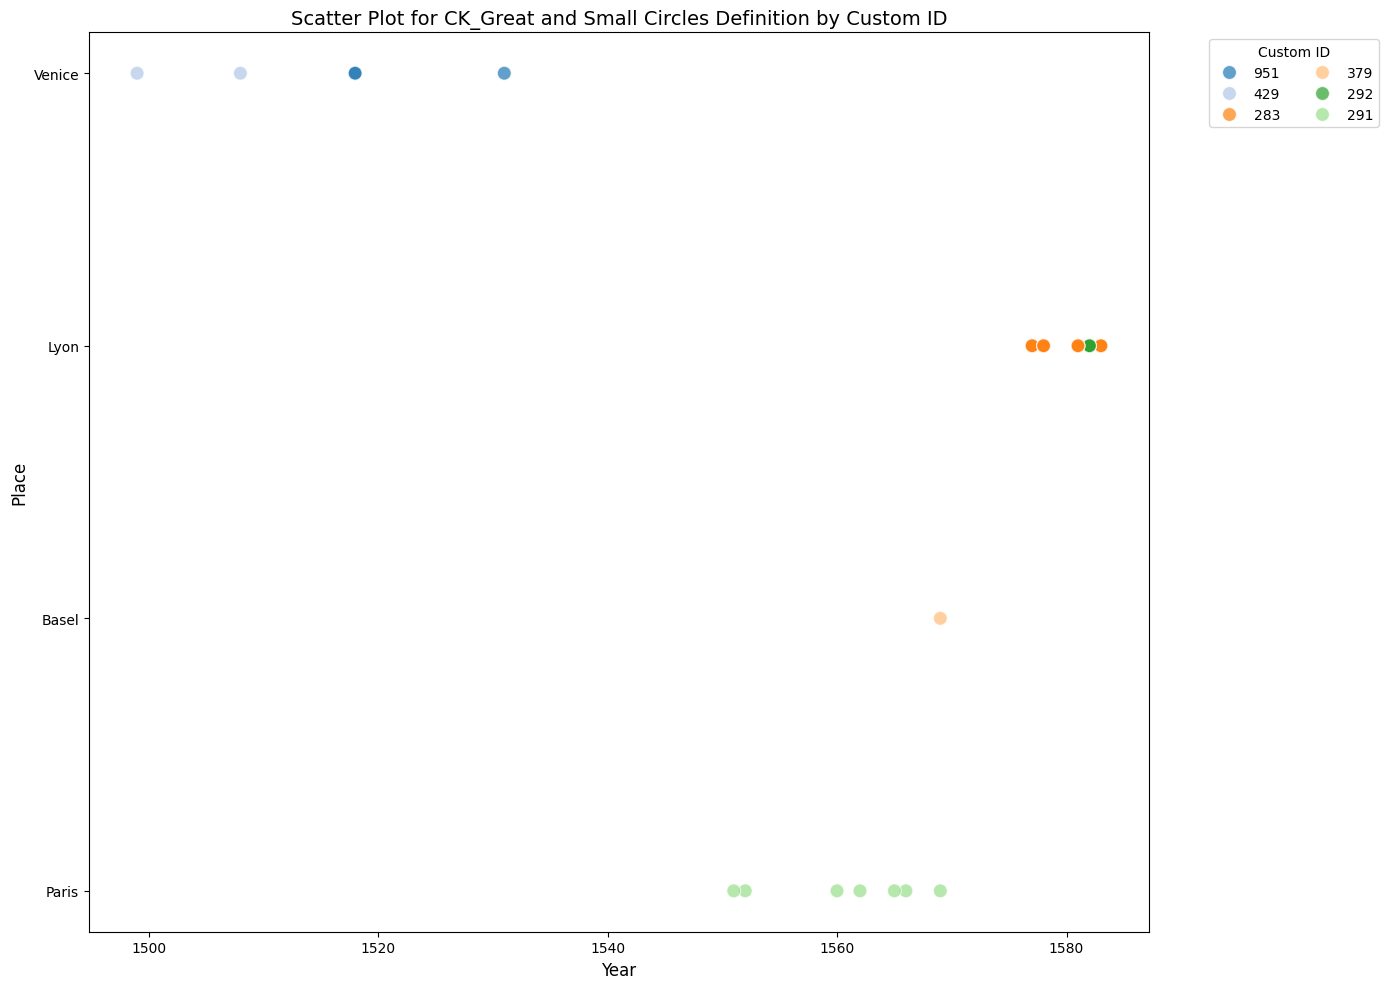

In [4]:
# Create the scatter plot using seaborn
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=filtered,
    x='year',
    y='place',
    hue='custom_identifier_str',
    palette='tab20',
    s=100,
    alpha=0.7
)

plt.title('Scatter Plot for CK_Great and Small Circles Definition by Custom ID', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Place', fontsize=12)
plt.legend(title='Custom ID', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

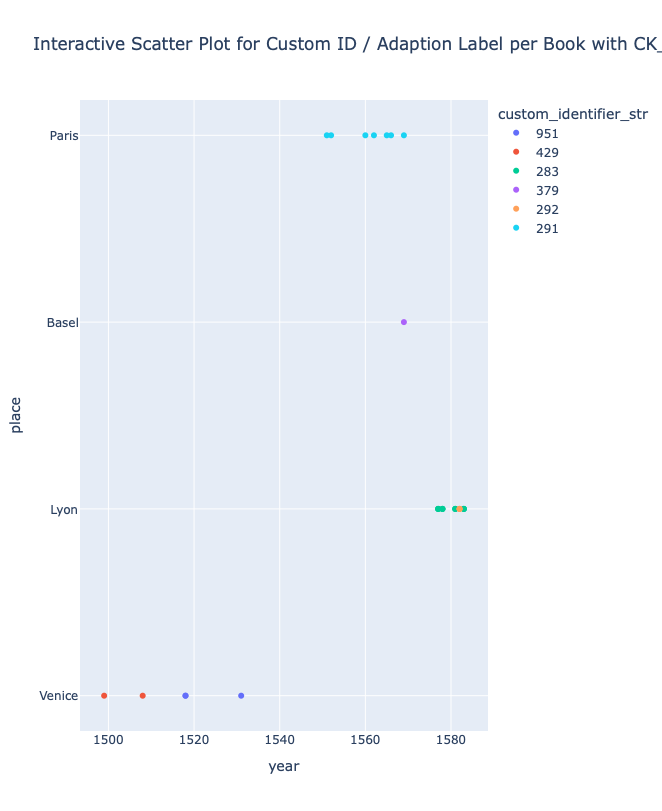

In [5]:
# Interactive scatter plot with plotly (with part or adaption label)
if 'part_or_adaption_label' in filtered.columns:
    hover_cols = ['part_or_adaption_label', 'images', 'custom_identifier', 'book']
else:
    hover_cols = ['images', 'custom_identifier', 'book']

fig = px.scatter(
    filtered,
    x='year',
    y='place',
    color='custom_identifier_str',
    hover_data=hover_cols,
    title='Interactive Scatter Plot for Custom ID / Adaption Label per Book with CK_Great and Small Circles Definition',
    height=800
)
fig.show()